# EMA EDA

Kendra wyant  
February 16, 2026

## Setup

In [ ]:
#| include: false

options(conflicts.policy = "depends.ok")
library(tidyverse) 

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

ℹ SHA-1 hash of file is "0faa14c0c44c2635216370888b7da9bfa8d07979"

## Read in data

In [ ]:
#| code-fold: true

ema <- read_csv(here::here(path_shared, "survey_daily.csv"), 
                show_col_types = FALSE) |> 
  mutate(start_date = with_tz(start_date,tzone = "America/Chicago"))

study_start <- read_csv(here::here(path_shared, "contact_log.csv"), 
                show_col_types = FALSE) |> 
  select(subid, onboarding) |> 
  filter(subid %in% ema$subid) |> 
  mutate(onboarding = as_date(onboarding, format = "%m/%d/%Y"))

ema_study_dates <- read_csv(here::here(path_shared, "study_dates_ema.csv"), 
                show_col_types = FALSE)
  
length(unique(ema$subid))

[1] 405

## EMA

In [ ]:
#| code-fold: true

ema <- ema |> 
  mutate(date = date(start_date)) |> 
  group_by(subid, date) |> 
  count() |> 
  mutate(n = if_else(n > 1, 1, n)) |> 
  ungroup() |> 
  left_join(study_start, by = "subid")

ema <- ema |> 
  left_join(ema_study_dates |> select(subid, study_end),
            by = "subid") |> 
  filter(!date > study_end)


ema_count <- ema |> 
  select(subid) |> 
  distinct() |> 
  left_join(ema |> 
  group_by(subid) |> 
  filter(date > onboarding & date < onboarding + days(7)) |> 
  count() |> 
  mutate(week = 1) |> 
  ungroup(), by = "subid") |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(7) & date < onboarding + days(14)) |> 
  count() |> 
  mutate(week = 2) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(14) & date < onboarding + days(21)) |> 
  count() |> 
  mutate(week = 3) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(21) & date < onboarding + days(28)) |> 
  count() |> 
  mutate(week = 4) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(28) & date < onboarding + days(35)) |> 
  count() |> 
  mutate(week = 5) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(35) & date < onboarding + days(42)) |> 
  count() |> 
  mutate(week = 6) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(42) & date < onboarding + days(49)) |> 
  count() |> 
  mutate(week = 7) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(49) & date < onboarding + days(56)) |> 
  count() |> 
  mutate(week = 8) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(56) & date < onboarding + days(63)) |> 
  count() |> 
  mutate(week = 9) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(63) & date < onboarding + days(70)) |> 
  count() |> 
  mutate(week = 10) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(70) & date < onboarding + days(77)) |> 
  count() |> 
  mutate(week = 11) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(77) & date < onboarding + days(84)) |> 
  count() |> 
  mutate(week = 12) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(84) & date < onboarding + days(91)) |> 
  count() |> 
  mutate(week = 13) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(91) & date < onboarding + days(98)) |> 
  count() |> 
  mutate(week = 14) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(98) & date < onboarding + days(105)) |> 
  count() |> 
  mutate(week = 15) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(105) & date < onboarding + days(112)) |> 
  count() |> 
  mutate(week = 16) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(112) & date < onboarding + days(119)) |> 
  count() |> 
  mutate(week = 17) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(119) & date < onboarding + days(126)) |> 
  count() |> 
  mutate(week = 18) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(126) & date < onboarding + days(133)) |> 
  count() |> 
  mutate(week = 19) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(133) & date < onboarding + days(140)) |> 
  count() |> 
  mutate(week = 20) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(140) & date < onboarding + days(147)) |> 
  count() |> 
  mutate(week = 21) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(147) & date < onboarding + days(154)) |> 
  count() |> 
  mutate(week = 22) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(154) & date < onboarding + days(161)) |> 
  count() |> 
  mutate(week = 23) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(161) & date < onboarding + days(168)) |> 
  count() |> 
  mutate(week = 24) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(168) & date < onboarding + days(175)) |> 
  count() |> 
  mutate(week = 25) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(175) & date < onboarding + days(182)) |> 
  count() |> 
  mutate(week = 26) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(182) & date < onboarding + days(189)) |> 
  count() |> 
  mutate(week = 27) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(189) & date < onboarding + days(196)) |> 
  count() |> 
  mutate(week = 28) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(196) & date < onboarding + days(203)) |> 
  count() |> 
  mutate(week = 29) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(203) & date < onboarding + days(210)) |> 
  count() |> 
  mutate(week = 30) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(210) & date < onboarding + days(217)) |> 
  count() |> 
  mutate(week = 31) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(217) & date < onboarding + days(224)) |> 
  count() |> 
  mutate(week = 32) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(224) & date < onboarding + days(231)) |> 
  count() |> 
  mutate(week = 33) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(231) & date < onboarding + days(238)) |> 
  count() |> 
  mutate(week = 34) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(238) & date < onboarding + days(245)) |> 
  count() |> 
  mutate(week = 35) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(245) & date < onboarding + days(252)) |> 
  count() |> 
  mutate(week = 36) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(252) & date < onboarding + days(259)) |> 
  count() |> 
  mutate(week = 37) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(259) & date < onboarding + days(266)) |> 
  count() |> 
  mutate(week = 38) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(266) & date < onboarding + days(273)) |> 
  count() |> 
  mutate(week = 39) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(273) & date < onboarding + days(280)) |> 
  count() |> 
  mutate(week = 40) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(280) & date < onboarding + days(287)) |> 
  count() |> 
  mutate(week = 41) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(287) & date < onboarding + days(294)) |> 
  count() |> 
  mutate(week = 42) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(294) & date < onboarding + days(301)) |> 
  count() |> 
  mutate(week = 43) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(301) & date < onboarding + days(308)) |> 
  count() |> 
  mutate(week = 44) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(308) & date < onboarding + days(315)) |> 
  count() |> 
  mutate(week = 45) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(315) & date < onboarding + days(322)) |> 
  count() |> 
  mutate(week = 46) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(322) & date < onboarding + days(329)) |> 
  count() |> 
  mutate(week = 47) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(329) & date < onboarding + days(336)) |> 
  count() |> 
  mutate(week = 48) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(336) & date < onboarding + days(343)) |> 
  count() |> 
  mutate(week = 49) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(343) & date < onboarding + days(350)) |> 
  count() |> 
  mutate(week = 50) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(350) & date < onboarding + days(357)) |> 
  count() |> 
  mutate(week = 51) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(357) & date < onboarding + days(364)) |> 
  count() |> 
  mutate(week = 52) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(364) & date < onboarding + days(371)) |> 
  count() |> 
  mutate(week = 53) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(371) & date < onboarding + days(378)) |> 
  count() |> 
  mutate(week = 54) |>  
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(378) & date < onboarding + days(385)) |> 
  count() |> 
  mutate(week = 55) |> 
  ungroup()) |>
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(385) & date < onboarding + days(392)) |> 
  count() |> 
  mutate(week = 56) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(392) & date < onboarding + days(399)) |> 
  count() |> 
  mutate(week = 57) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(399) & date < onboarding + days(406)) |> 
  count() |> 
  mutate(week = 58) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(406) & date < onboarding + days(413)) |> 
  count() |> 
  mutate(week = 59) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(413) & date < onboarding + days(420)) |> 
  count() |> 
  mutate(week = 60) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(420) & date < onboarding + days(427)) |> 
  count() |> 
  mutate(week = 61) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(427) & date < onboarding + days(434)) |> 
  count() |> 
  mutate(week = 62) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(434) & date < onboarding + days(441)) |> 
  count() |> 
  mutate(week = 63) |> 
  ungroup()) |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(441) & date < onboarding + days(448)) |> 
  count() |> 
  mutate(week = 64) |> 
  ungroup())  |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(448) & date < onboarding + days(455)) |> 
  count() |> 
  mutate(week = 65) |> 
  ungroup())  |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(455) & date < onboarding + days(462)) |> 
  count() |> 
  mutate(week = 66) |> 
  ungroup())  |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(462) & date < onboarding + days(469)) |> 
  count() |> 
  mutate(week = 67) |> 
  ungroup())  |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(469) & date < onboarding + days(476)) |> 
  count() |> 
  mutate(week = 68) |> 
  ungroup())  |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(476) & date < onboarding + days(483)) |> 
  count() |> 
  mutate(week = 69) |> 
  ungroup())  |> 
  bind_rows(ema |> 
  group_by(subid) |> 
  filter(date >= onboarding + days(483) & date < onboarding + days(490)) |> 
  count() |> 
  mutate(week = 70) |> 
  ungroup())

In [ ]:
#| code-fold: true
#| warning: false

sub_group_1 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(1:30) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_2 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(31:60) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_3 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(61:90) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_4 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(91:120) |> 
  pull(subid)

sub_group_5 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(121:150) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_6 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(151:180) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_7 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(181:210) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_8 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(211:240) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_9 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(241:270) |> 
  pull(subid)

sub_group_10 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(271:300) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_11 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(301:331) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_12 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(331:360) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_13 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(361:390) |> 
  arrange(subid) |> 
  pull(subid)

sub_group_14 <- ema_count |> 
  select(subid) |> 
  distinct() |> 
  arrange(desc(subid)) |> 
  slice(391:420) |> 
  arrange(subid) |> 
  pull(subid)

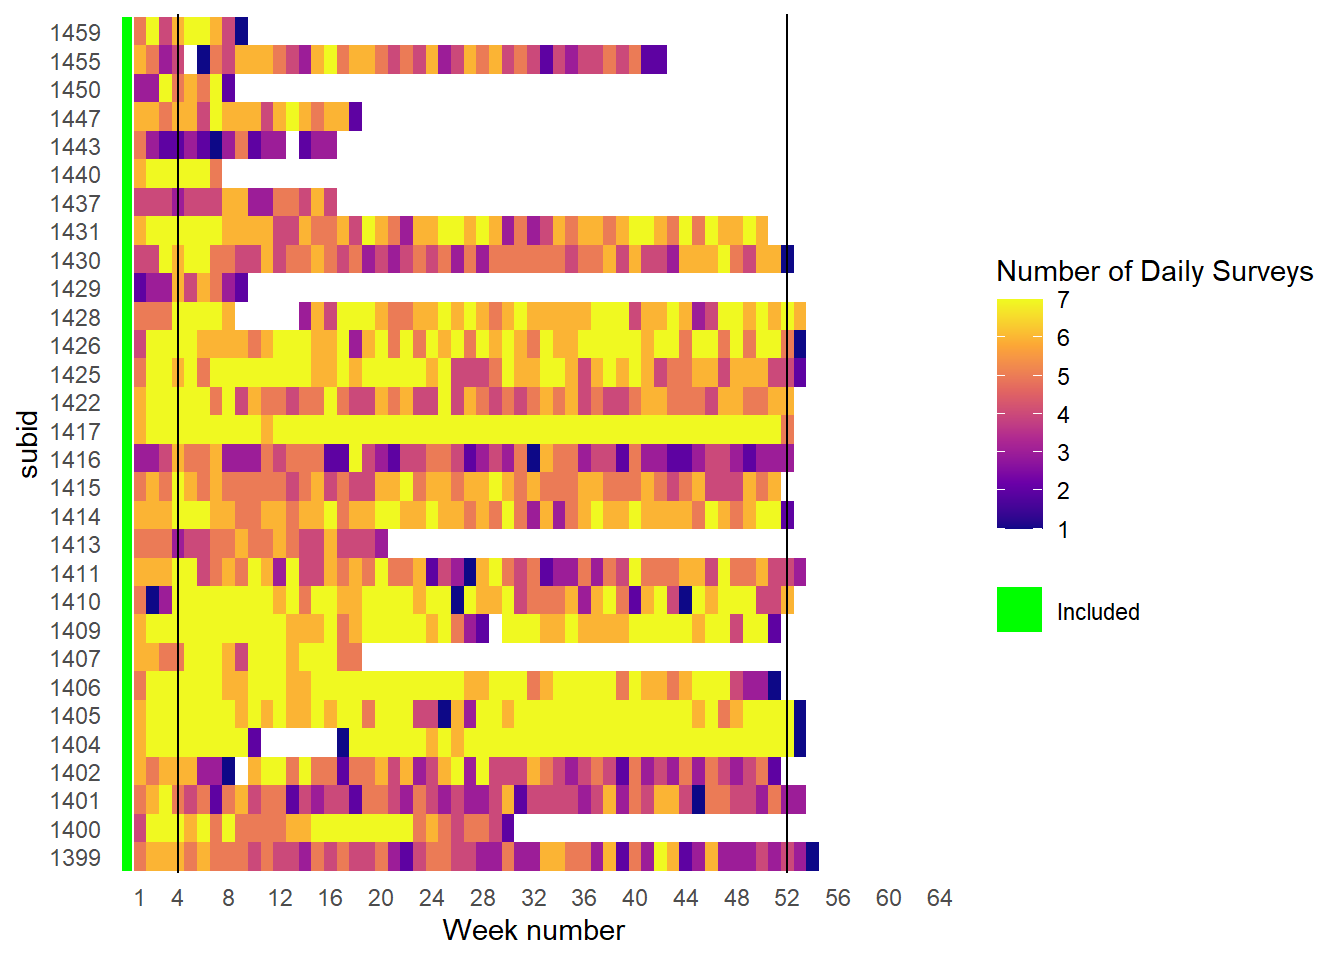

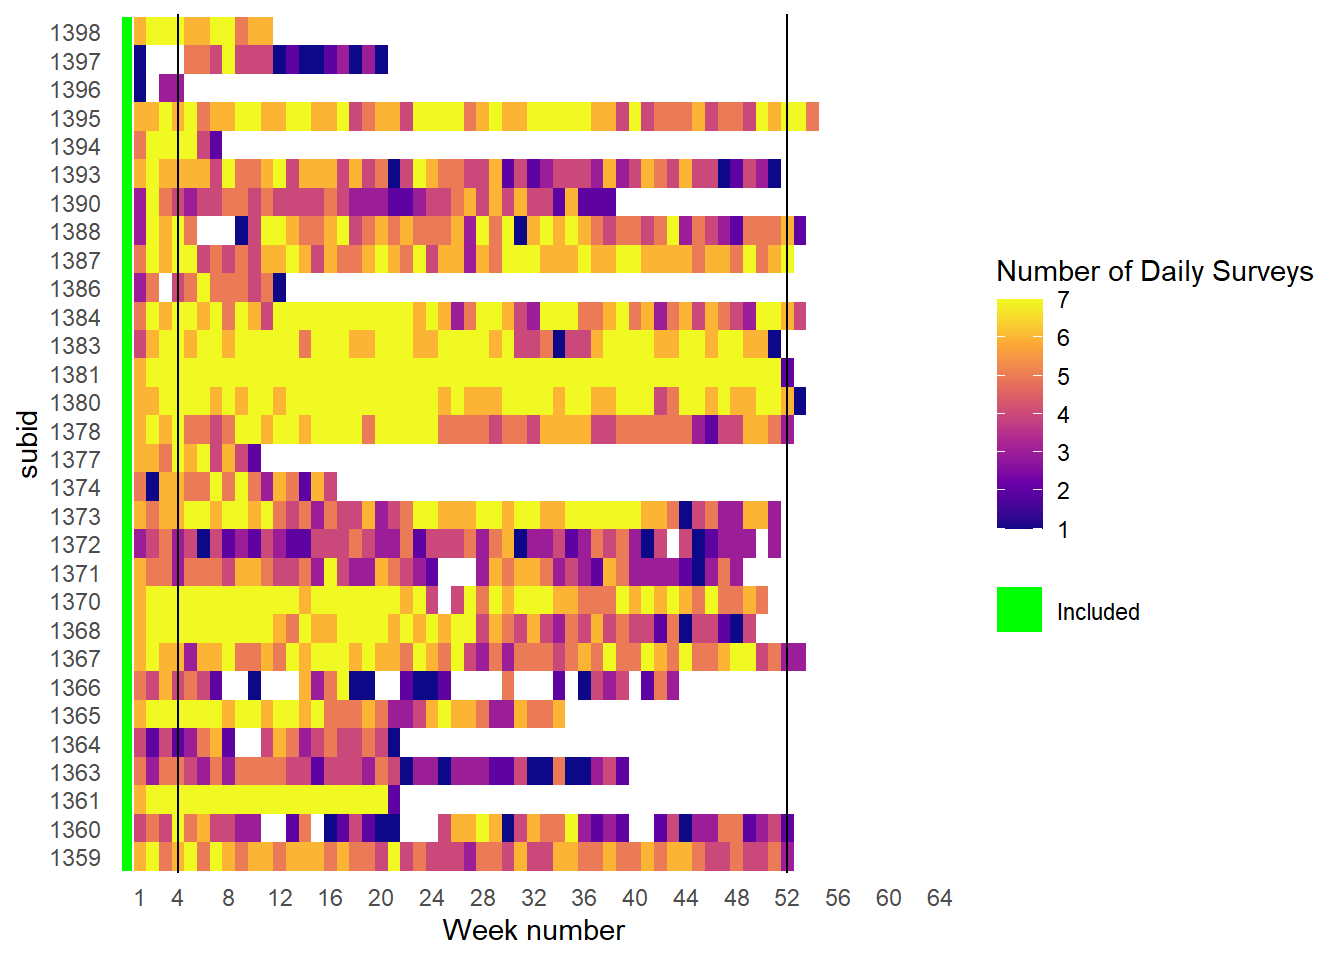

(`geom_tile()`).

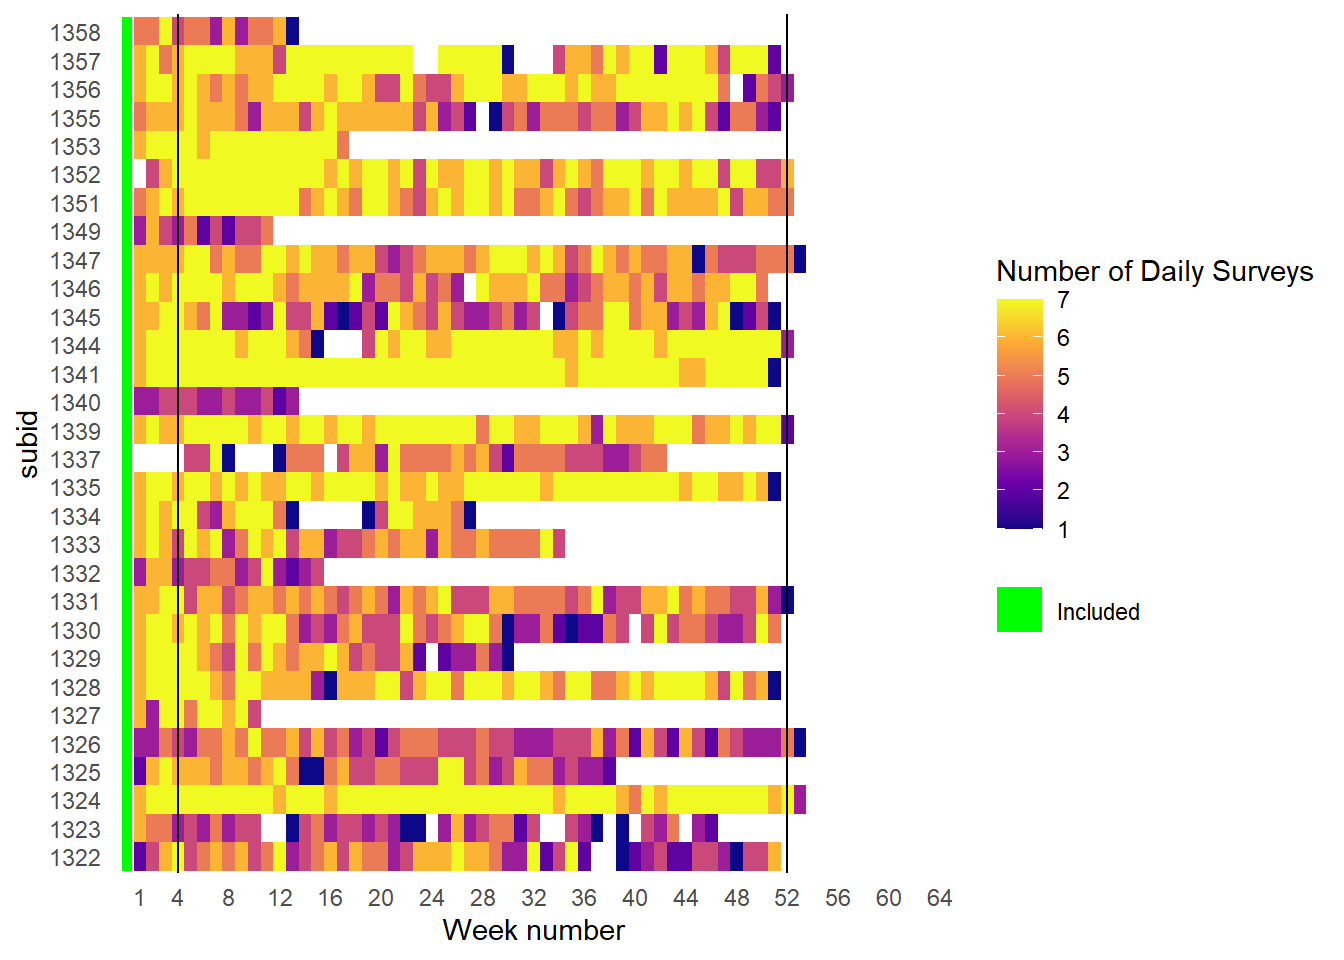

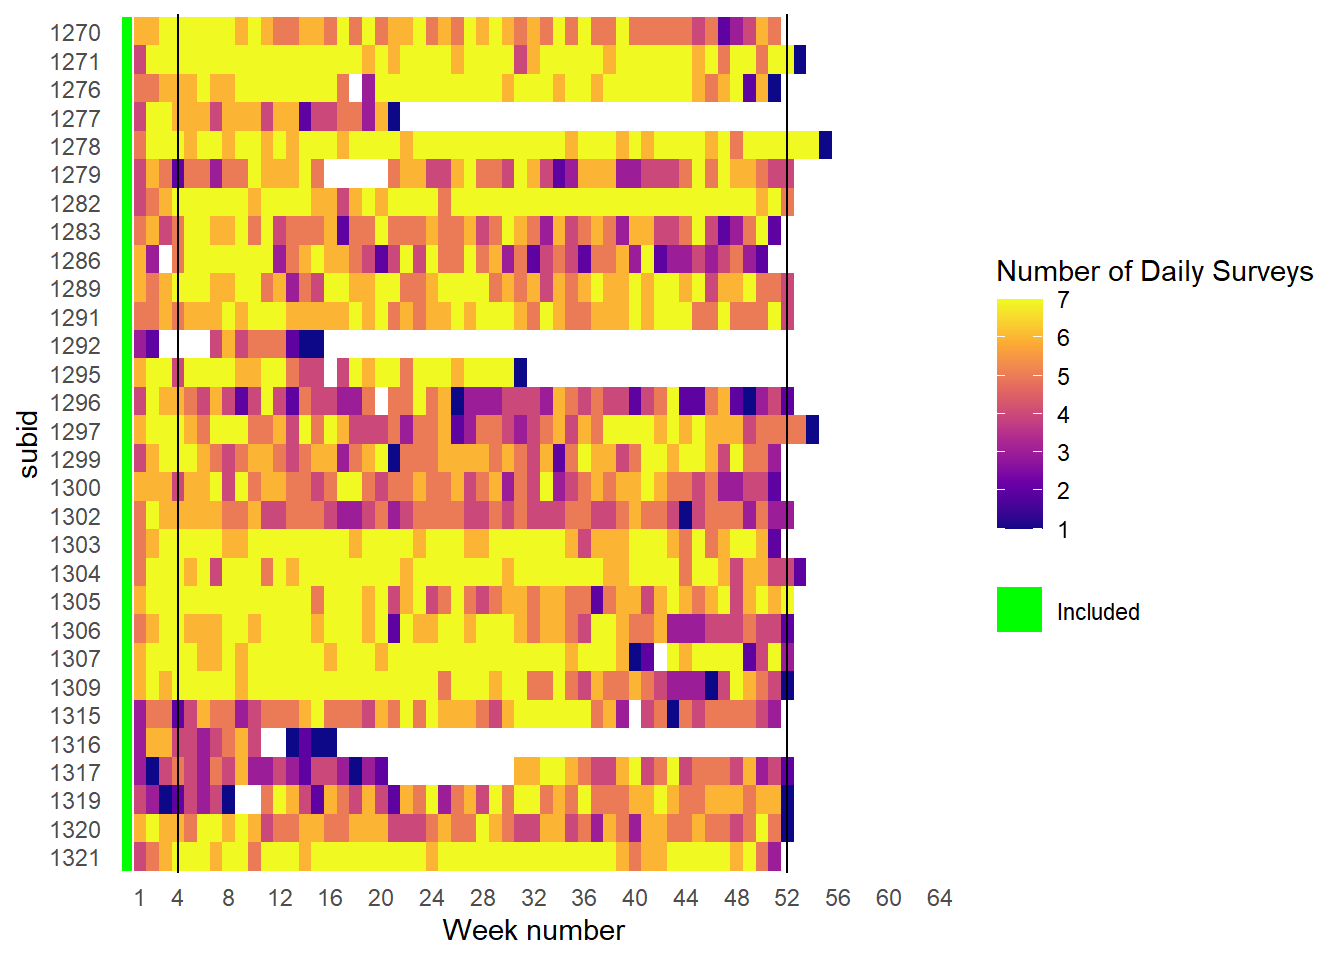

(`geom_tile()`).

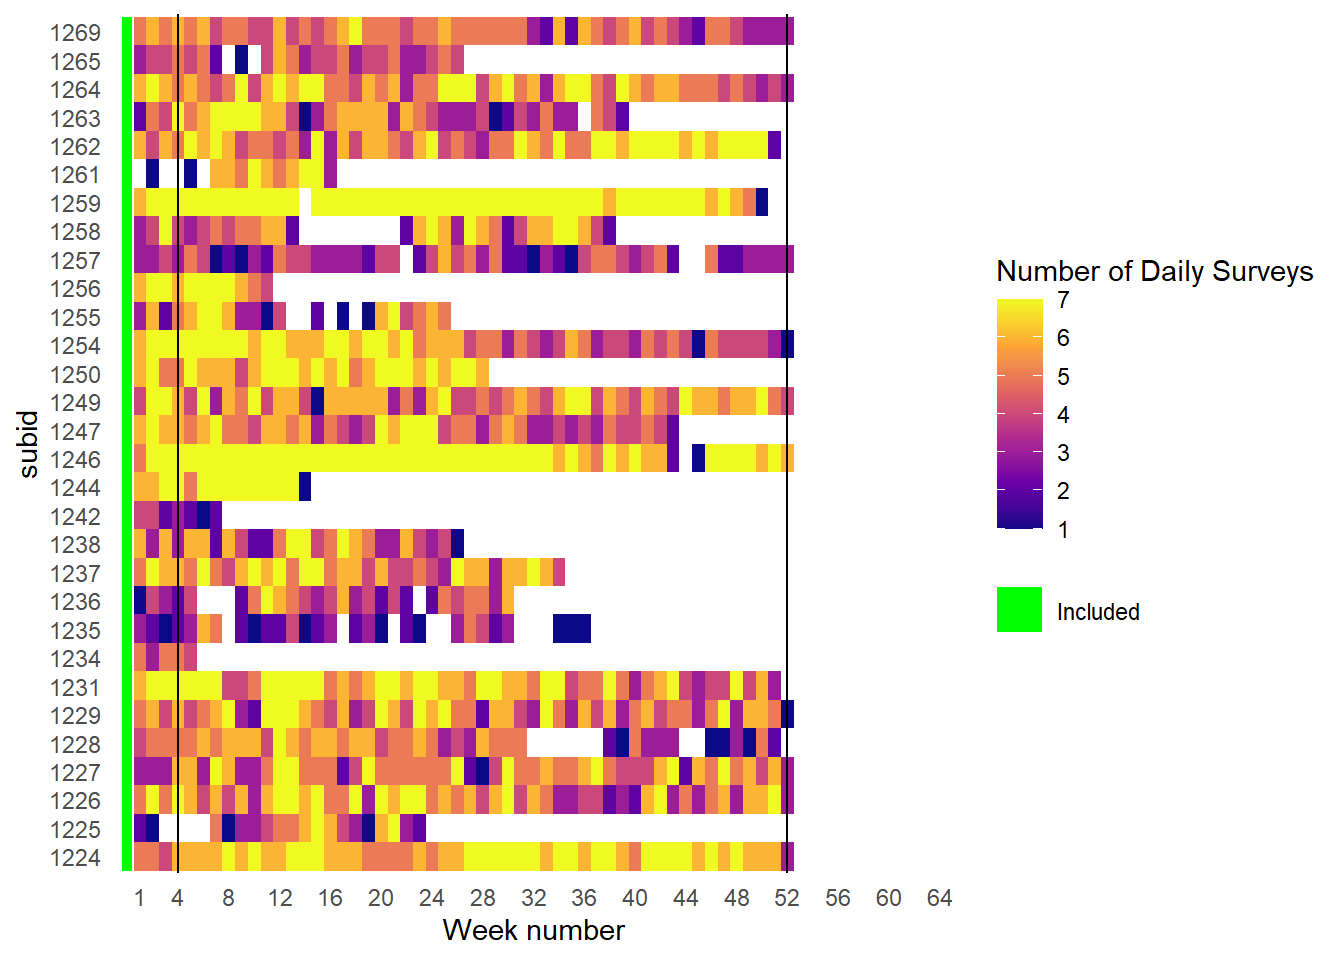

(`geom_tile()`).

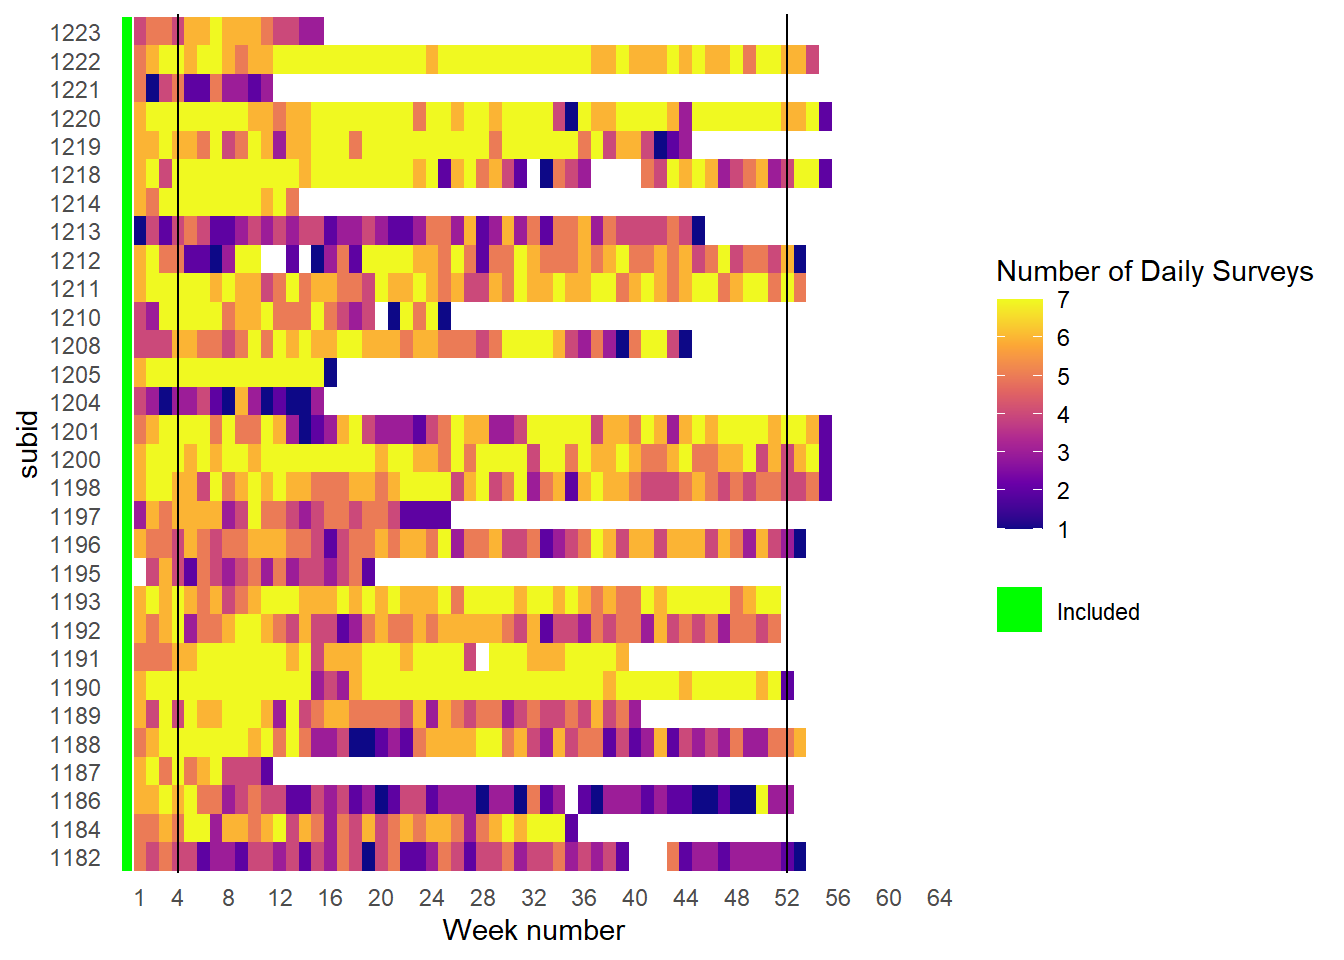

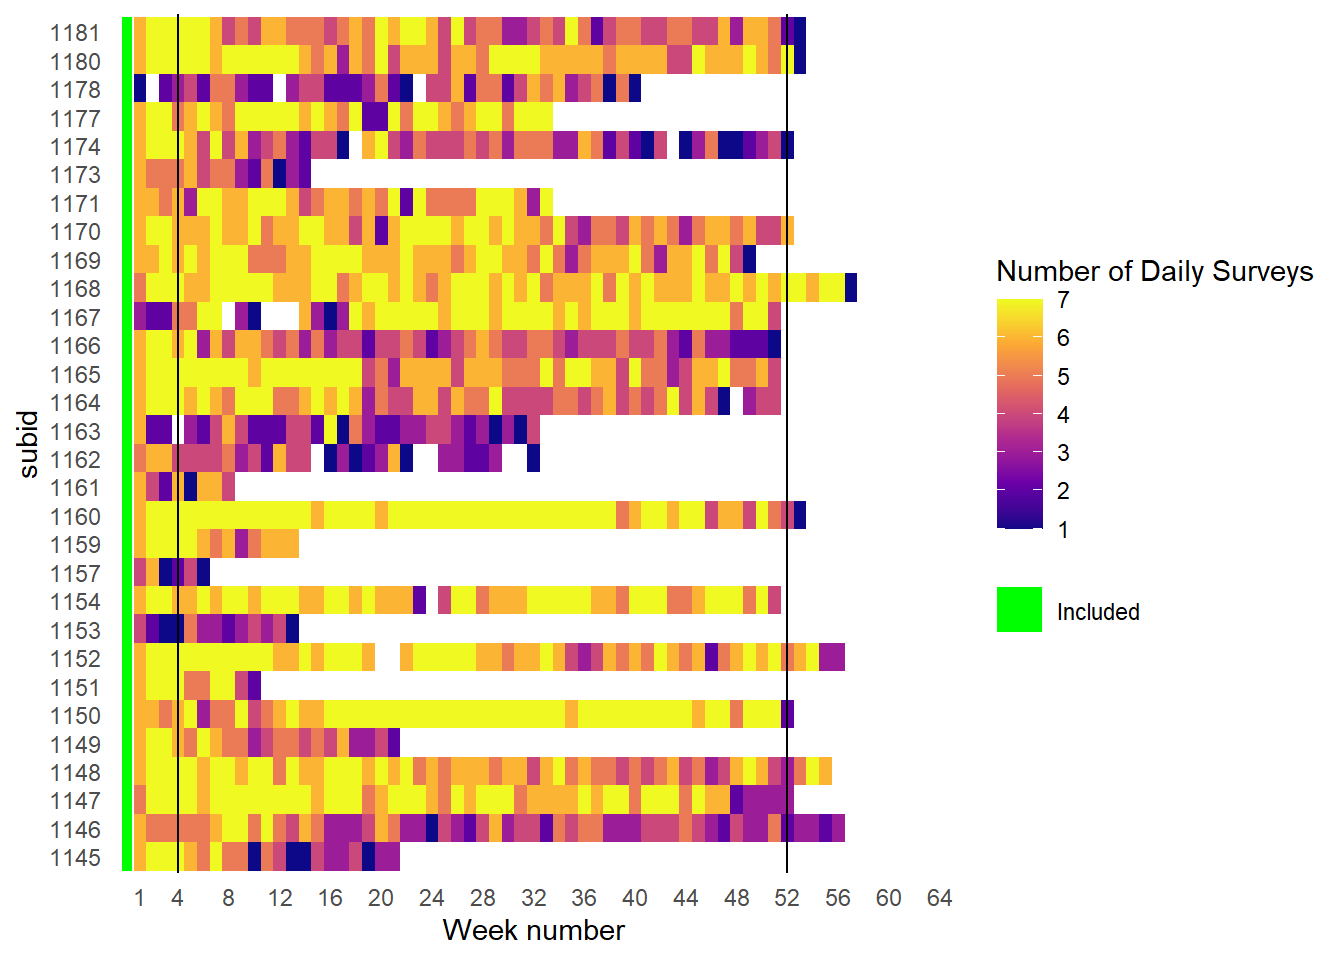

(`geom_tile()`).

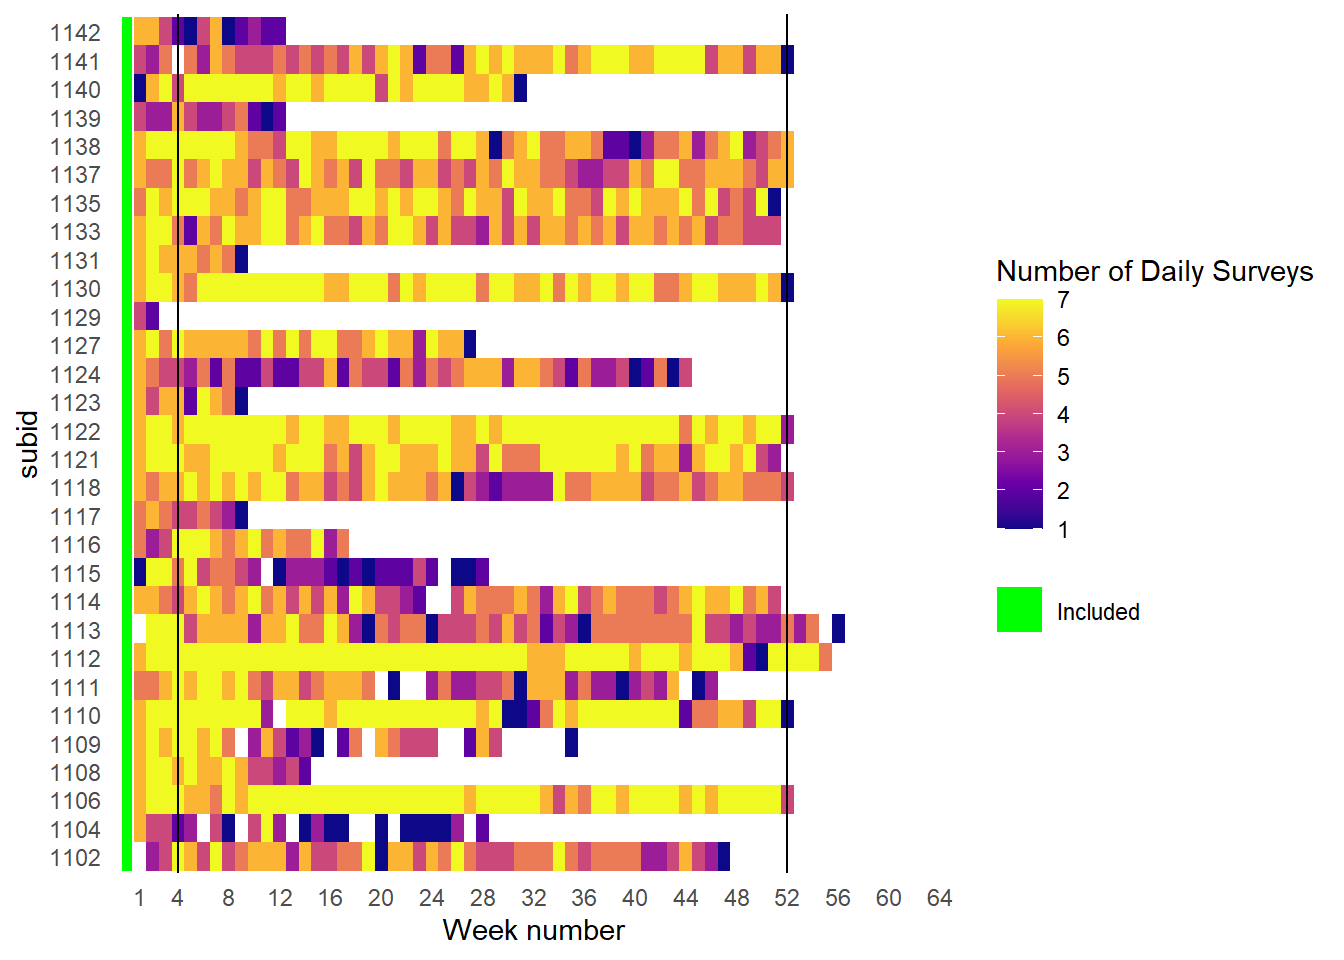

(`geom_tile()`).

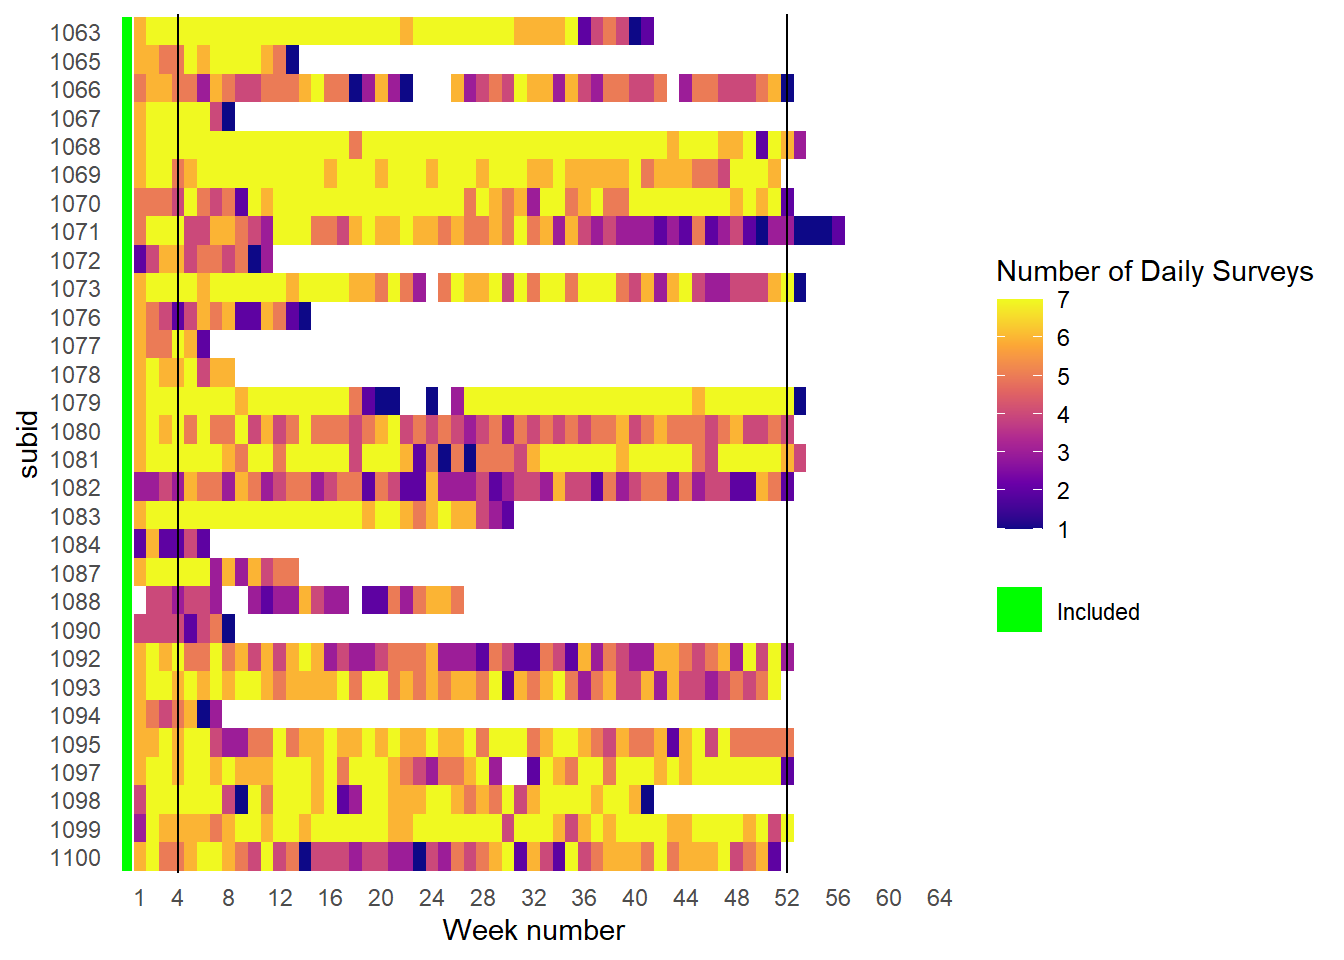

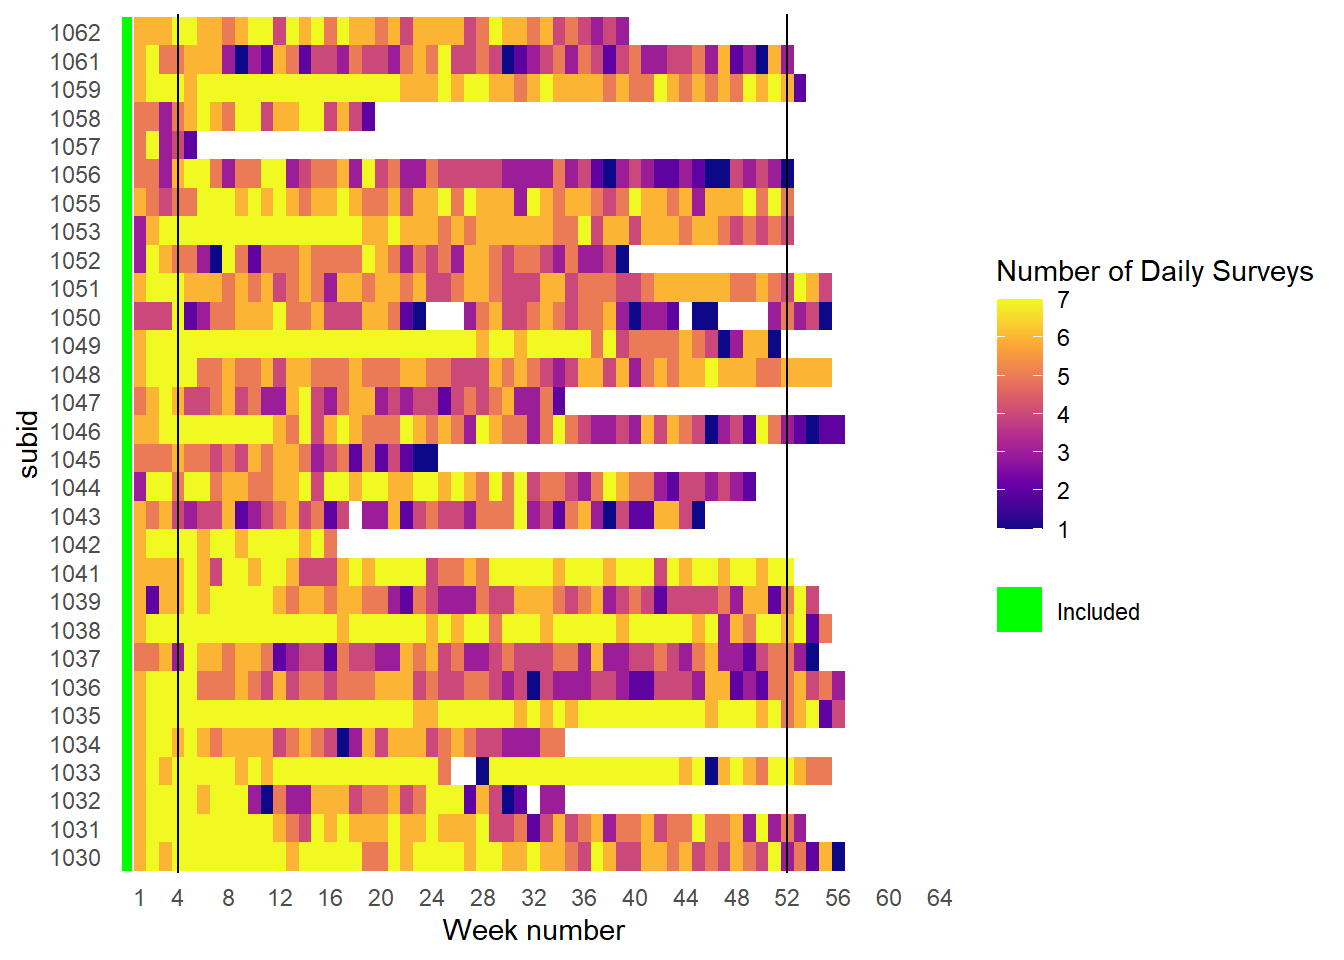

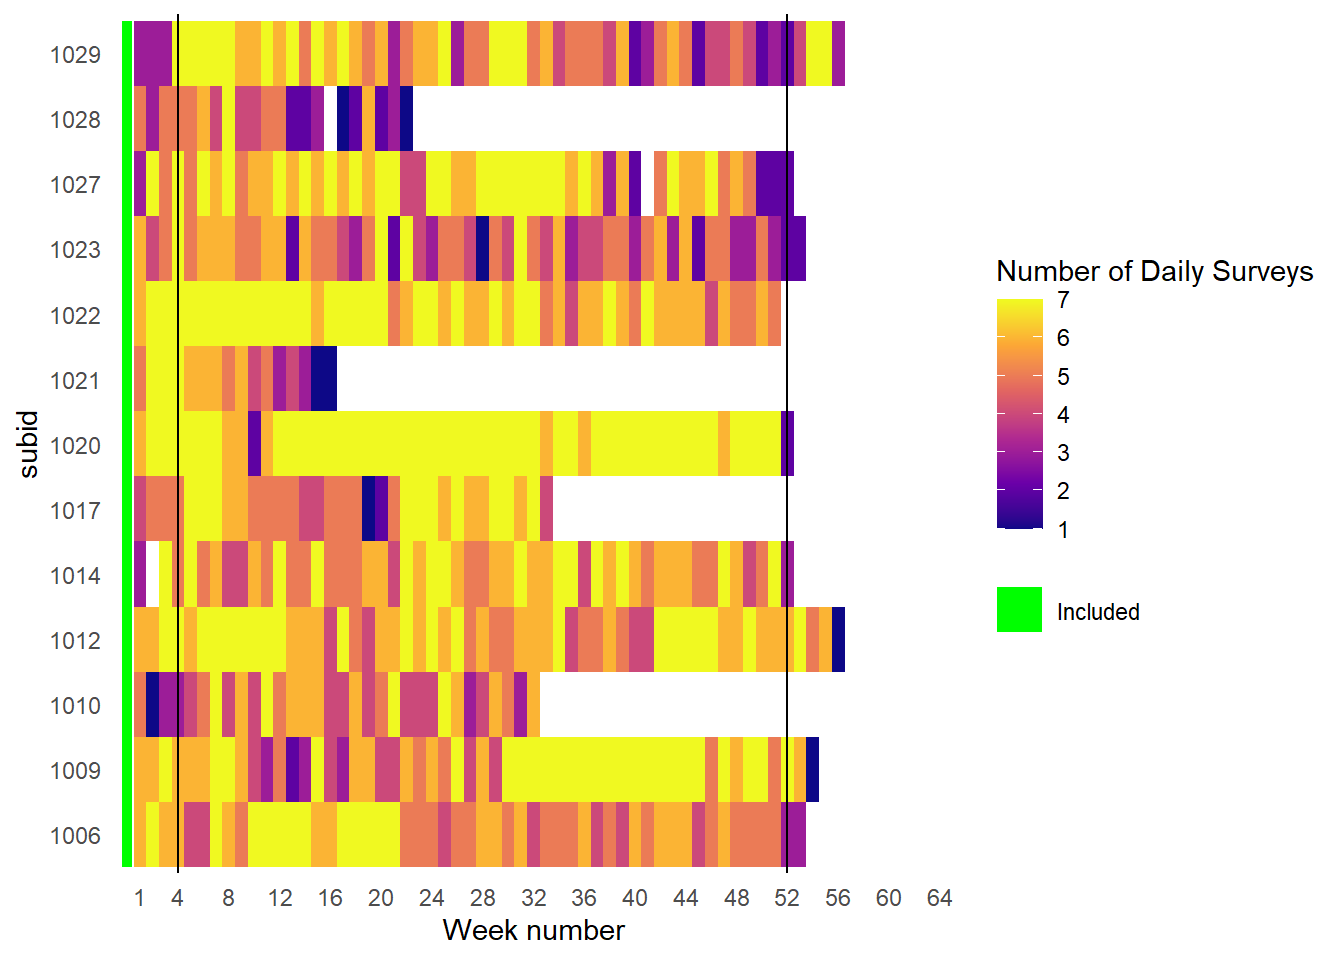

data's fill values.

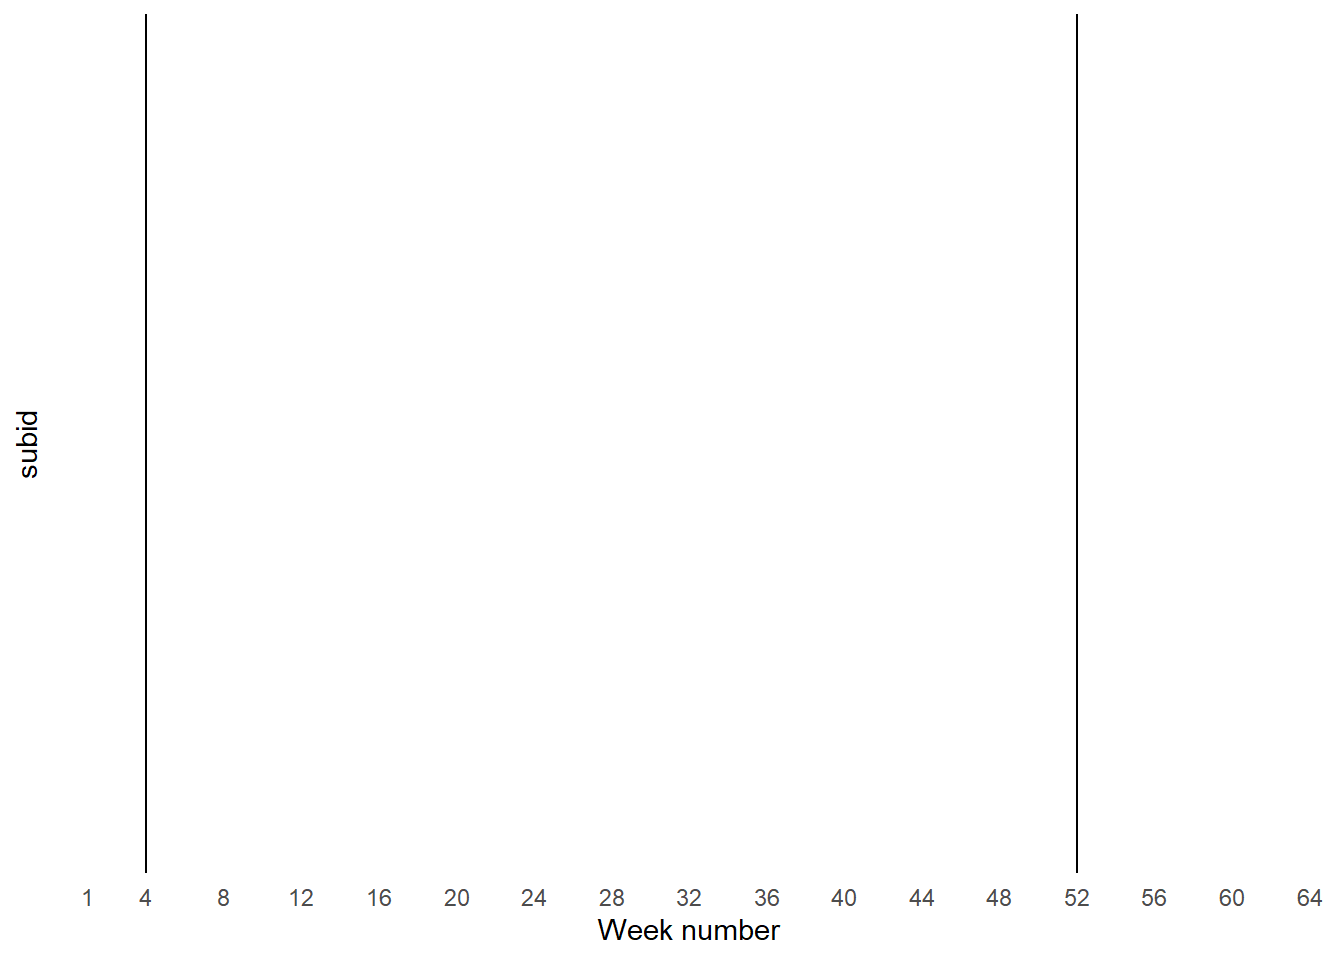

data's fill values.

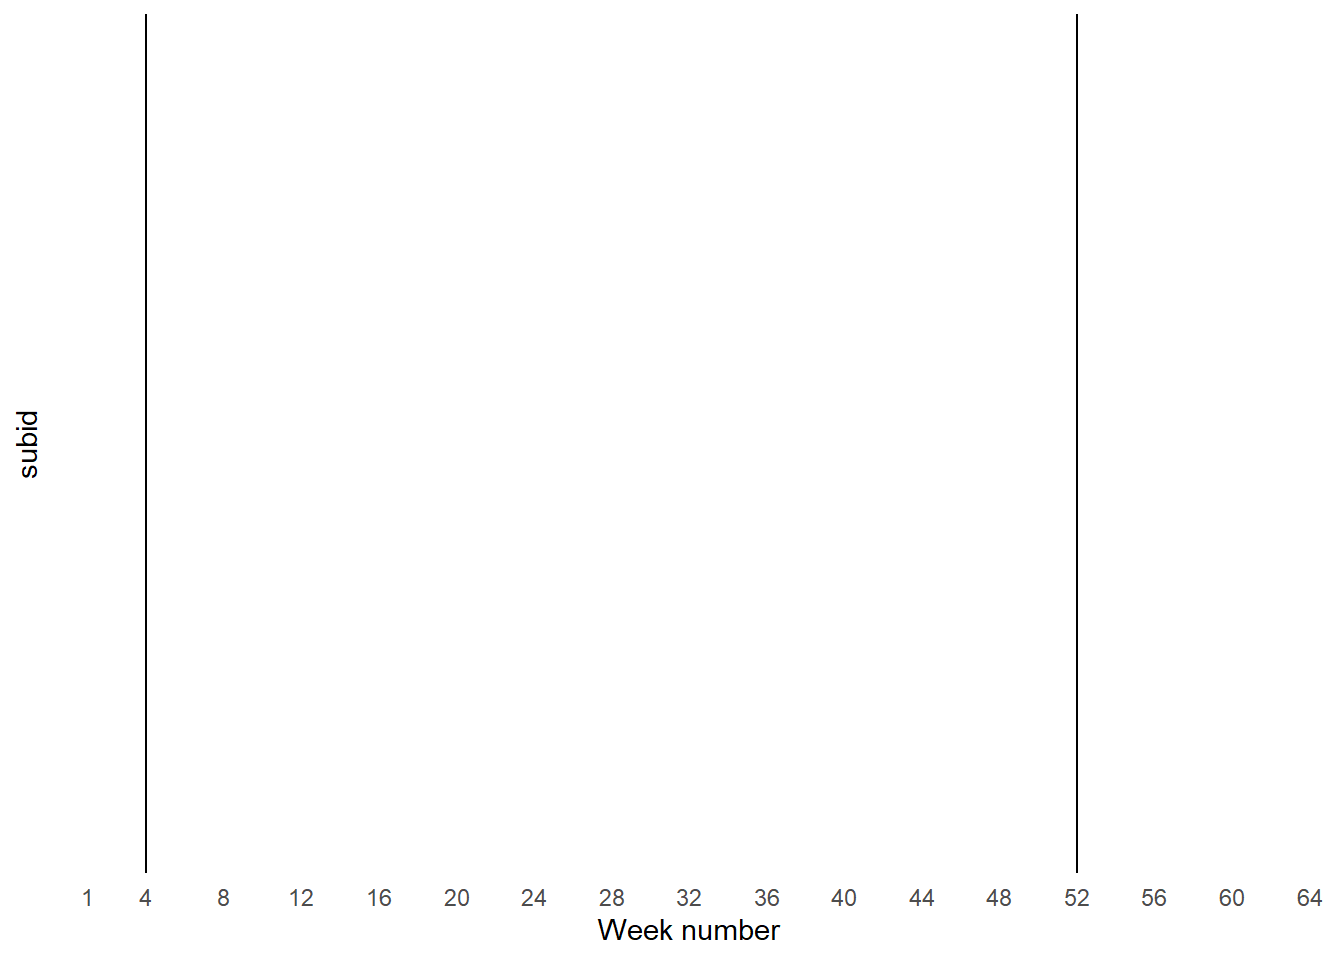

data's fill values.

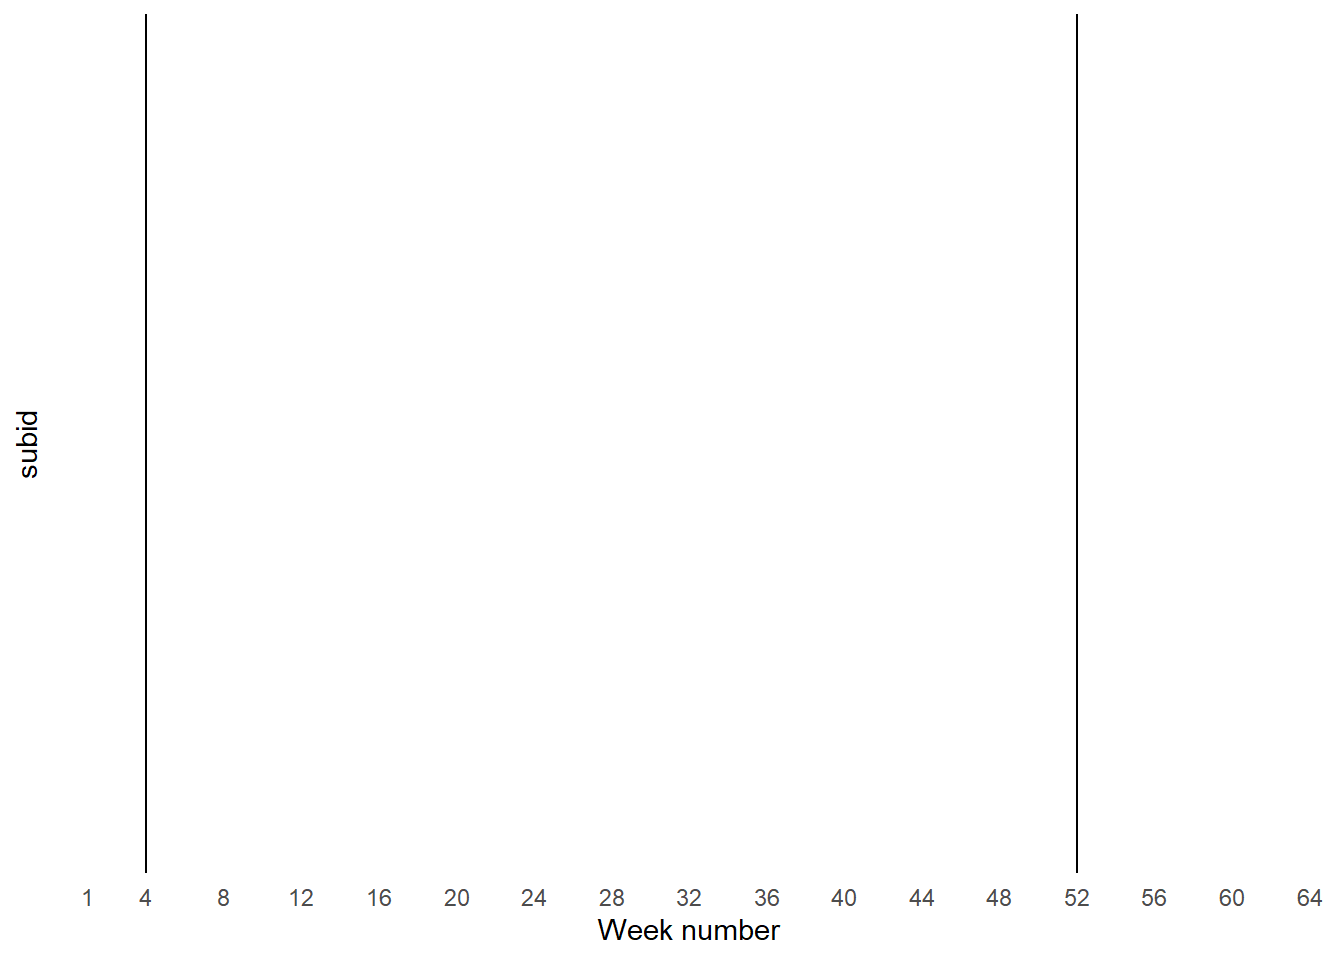

In [ ]:
#| code-fold: true
#| warning: false

sub_key <- ema_count |> 
  distinct(subid) |> 
  mutate(group = if_else(subid %in% ema_study_dates$subid, "Included", "Excluded"))

ema_count <- ema_count |> 
  left_join(sub_key, by = "subid") 

strip <- ema_count |> 
  distinct(subid, group) |> 
  mutate(week = 0, count = NA_real_)


ggplot() +
 geom_tile(data = strip |>
             filter(subid %in% sub_group_1) |> 
             mutate(subid = factor(subid, levels = sub_group_1)),
    aes(x = week, y = subid, fill = group),
    width = 0.8) +
  scale_fill_manual(
    values = c(Included = "green", Excluded = "red"),
    name = NULL) +
  ggnewscale::new_scale_fill() +
  geom_tile(data = ema_count |>
              filter(subid %in% sub_group_1) |> 
              mutate(subid = factor(subid, levels = sub_group_1)),
            aes(x = week, y = subid, fill = n)) +
  scale_fill_viridis_c(option = "C",
                       name = "Number of Daily Surveys",
                       na.value = "white") +
  scale_x_continuous(
    breaks = c(1, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64),
    limits = c(-1, 65),
    expand = c(0, 0)
  ) +
  labs(x = "Week number", y = "subid") +
  theme_minimal() +
  theme(panel.grid = element_blank()) +
  geom_vline(xintercept = 4) +
  geom_vline(xintercept = 52)

## Monthly Surveys

33 people missing more than 3 monthly surveys total

No notes as to why missing more than 3

In [ ]:
contact_log <- read_csv(here::here(path_shared, "contact_log.csv"), 
                show_col_types = FALSE) |> 
  mutate(expected_monthly = floor(days_on_study/30),
         expected_monthly = if_else(expected_monthly > 12, 12, expected_monthly))

contact_log |> 
  filter(num_monthly_surveys < expected_monthly - 3) |> 
  nrow()

[1] 33

# A tibble: 33 × 3
   subid num_monthly_surveys expected_monthly
   <dbl>               <dbl>            <dbl>
 1  1056                   4               12
 2  1100                   7               11
 3  1121                   8               12
 4  1137                   7               12
 5  1174                   6               12
 6  1186                   8               12
 7  1192                   7               11
 8  1196                   8               12
 9  1198                   8               12
10  1227                   8               12
11  1259                   6               11
12  1264                   8               12
13  1270                   7               12
14  1271                   6               12
15  1283                   5               11
16  1291                   8               12
17  1317                   8               12
18  1335                   3               11
19  1346                   6               12
20  1347       